<a href="https://colab.research.google.com/github/chomingi-25/2026_tues_bigdatacomputing_class/blob/main/%EB%8B%A4%EC%A4%91_%ED%8A%B9%EC%84%B1_%ED%9A%8C%EA%B7%80_%EB%AA%A8%EB%8D%B8_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EA%B5%AC%EC%B6%95_%EB%B0%8F_Streamlit_%EC%9B%B9_%EC%84%9C%EB%B9%84%EC%8A%A4_%EB%B0%B0%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0단계
- 실습 환경 구축

In [1]:
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.9 MB/s eta 0:00:00


## 1단계
- 데이터 준비 및 소규모 훈련 샘플링
- 파이프라인 기반 모델 3종 학습 및 저장

In [2]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 로드
url="https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df=pd.read_csv(url) # CSV 파일 읽기
df.columns = df.columns.str.strip() # 컬럼명 앞뒤 공백 제거
df=df.dropna() # 결측치 제거
features=['Adult mortality', 'BMI', 'GDP', 'Alcohol'] # 사용할 독립변수 선택
target='Life expectancy' # 종속변수 선택
X=df[features] # 독립변수 데이터 저장
y=df[target] # 종속변수 데이터 저장
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=50) # 학습용 80%, 테스트용 20% 분할
X_train_small=X_train.sample(n=50, random_state=50) # 학습 데이터 중 50개만 무작위 추출
y_train_small=y_train.loc[X_train_small.index] # 추출된 학습 데이터에 대응하는 y값 추출
# 2. 모델 생성
models={
    # 선형회귀 모델
    "Linear": Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("model", LinearRegression()) # 선형회귀 적용
    ]),
    # 다항회귀 모델
    "Poly": Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("poly", PolynomialFeatures(degree=3)), # 3차 다항 특성 생성
        ("model", LinearRegression()) # 선형회귀 적용
    ]),
    # Ridge 모델
    "Ridge": Pipeline([
        ("scaler", StandardScaler()), # 데이터 표준화
        ("poly", PolynomialFeatures(degree=3)), # 3차 다항 특성 생성
        ("model", Ridge(alpha=1.0)) # Ridge 규제 적용
    ])
}
# 3. 모델 학습
trained_models={} # 학습된 모델 저장용 딕셔너리
# 3-1. 각 모델 반복 학습
for name, model in models.items():
  model.fit(X_train_small, y_train_small) # 50개 샘플로 모델 학습
  trained_models[name]=model # 학습된 모델 저장
# 4. 성능 비교 데이터 생성
results=[] # 성능 결과 저장용 리스트
# 4-1. 저장된 모델들을 하나씩 반복
for name, model in trained_models.items():
  train_pred=model.predict(X_train_small) # 학습 데이터 예측
  test_pred=model.predict(X_test) # 테스트 데이터 예측
  train_r2=r2_score(y_train_small, train_pred) # 학습 데이터 결정계수 계산
  test_r2=r2_score(y_test, test_pred) # # 테스트 데이터 결정계수 계산
  train_mse=mean_squared_error(y_train_small, train_pred) # 학습 데이터 평균제곱오차(MSE) 계산
  test_mse=mean_squared_error(y_test, test_pred) # 테스트 데이터 평균제곱오차(MSE) 계산
  # 4-2-1. 선형회귀 모델인 경우
  if name=="Linear":
    complexity=X_train_small.shape[1] # 원본 특성 개수 저장
  # 4-2-2. 다항회귀 또는 Ridge 모델인 경우
  else:
    complexity=model.named_steps["poly"].fit_transform(X_train_small).shape[1] # Polynomial Features 적용 후 생성된 특성 개수 확인
  results.append([
      name, # 모델 이름
      train_r2, # 학습 데이터 결정계수
      test_r2, # 테스트 데이터 결정계수
      train_mse, # 학습 데이터 MSE
      test_mse, # 테스트 데이터 MSE
      complexity # 모델 복잡도(특성 개수)
  ]) # 결과 리스트에 저장
results_df=pd.DataFrame(
    results, # 저장된 결과 사용
    columns=[   # 컬럼 이름 지정
        "Model",
        "Train R2",
        "Test R2",
        "Train MSE",
        "Test MSE",
        "Complexity"
    ]
) # 결과를 데이터프레임으로 변환
# 5. payload로 묶어서 저장
payload={
    "models" : trained_models,  # 학습된 모델들 저장
    "results_df": results_df,   # 성능 비교 결과 저장
    "features" : features,      # 사용한 독립변수 목록 저장
    "X_train": X_train,         # 학습 데이터 저장
    "X_test" : X_test           # 테스트 데이터 저장
}
# 6. payload 객체를 pkl 파일로 저장
joblib.dump(
    payload, # 저장할 객체
    "life_expectancy_models.pkl"  # 저장 파일명
)

# 7. 저장 완료 메시지 출력
print("life_expectancy_models.pkl 저장 완료")

life_expectancy_models.pkl 저장 완료


## 2단계
- 모델 성능 비교

=== 모델 성능 비교 ===


,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.7517,0.5564,21.2312,28.8675,4
1,Poly,0.9653,-267.0498,2.9690,17444.3002,35
2,Ridge,0.9468,0.3930,4.5459,39.5027,35


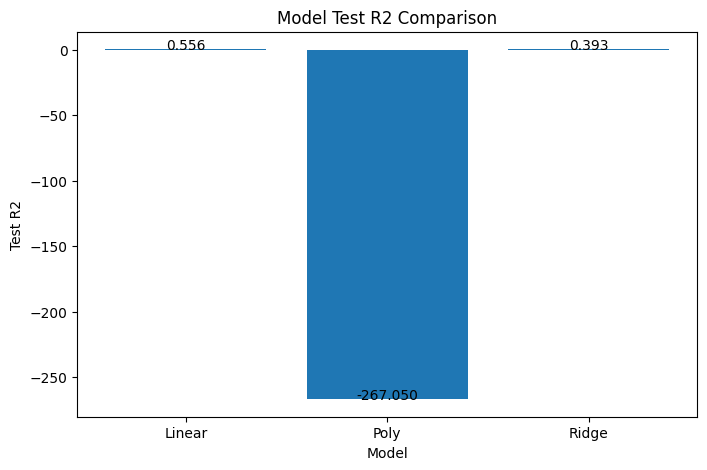


=== 최고 성능 모델 ===
모델 : Linear
Test R2 : 0.5564
Test MSE : 28.8675
Complexity : 4


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 로드
url="https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df=pd.read_csv(url)
df=df.dropna()
X=df[[
    "Adult mortality",
    "BMI",
    "GDP",
    "Alcohol"
]]
y=df["Life expectancy"]

# 2. 데이터 분할
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=50)

# 3. 모델 생성
linear_model=Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
poly_model=Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", LinearRegression())
])
ridge_model=Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", Ridge(alpha=1.0))
])
# 4. 모델 성능 비교
models={
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
} # 비교할 모델들을 딕셔너리 형태로 저장
results=[] # 성능 결과 저장용 리스트 생성
X_train_small=X_train.sample(n=50, random_state=50) # 학습 데이터 중 50개만 무작위 추출
y_train_small=y_train.loc[X_train_small.index] # 추출된 50개 X 데이터에 해당하는 y값 선택
for name, model in models.items():     # models 딕셔너리에서 모델 이름과 모델 객체를 하나씩 꺼냄
  model.fit(X_train_small, y_train_small) # 50개 학습 데이터로 모델 학습
  train_pred=model.predict(X_train_small) # 학습 데이터에 대한 예측값 생성
  test_pred=model.predict(X_test)      # 테스트 데이터에 대한 예측값 생성
  train_r2=r2_score(y_train_small, train_pred)  # 학습 데이터의 R2 점수 계산
  test_r2=r2_score(y_test, test_pred)  # 테스트 데이터의 R2 점수 계산
  train_mse=mean_squared_error(y_train_small, train_pred)  # 학습 데이터의 MSE 계산
  test_mse=mean_squared_error(y_test, test_pred)   # 테스트 데이터의 MSE 계산
  if name=="Linear":
    complexity=X_train_small.shape[1] # 원본 특성 개수 저장
  else:
    complexity=model.named_steps['poly'].fit_transform(X_train_small).shape[1] # 다항 회귀 모델로 변환 후 특성 개수
  results.append({ # 성능 결과를 딕셔너리 형태로 리스트에 추가
      "Model": name,    # 모델 이름 저장
      "Train R2": round(train_r2, 4),    # 학습 데이터 R2를 소수점 4자리로 저장
      "Test R2": round(test_r2, 4),      # 테스트 데이터 R2를 소수점 4자리로 저장
      "Train MSE": round(train_mse, 4),  # 학습 데이터 MSE를 소수점 4자리로 저장
      "Test MSE": round(test_mse, 4),    # 테스트 데이터 MSE를 소수점 4자리로 저장
      "Complexity": complexity           # 모델 복잡도 저장
  })   # 현재 모델의 성능 결과 저장 완료
result_df=pd.DataFrame(results) # 결과를 데이터프레임으로 변환
# 모델 성능 비교 결과 출력
print("=== 모델 성능 비교 ===")  # 출력 제목 표시
display(result_df) # 성능 비교 테이블 출력
plot_df=result_df.copy()
plot_df["Test R2"]=pd.to_numeric(plot_df["Test R2"])
plt.figure(figsize=(8, 5)) # 막대그래프 크기 설정
plt.bar(
    plot_df["Model"],    # x축 : 모델 이름
    plot_df["Test R2"]  # y축 : 테스트 R2
) # 모델별 Test R2 비교 그래프 생성
for i, v in enumerate(result_df["Test R2"]):   # 각 막대 위에 수치 표시
  plt.text(i, v, "{:.3f}".format(v), ha="center")  # 텍스트 출력 및 중앙 배열
plt.title("Model Test R2 Comparison") # 그래프 제목 설정
plt.xlabel("Model") # x축 이름 설정
plt.ylabel("Test R2") # y축 이름 설정
plt.show() # 그래프 출력
best_idx=result_df["Test R2"].idxmax() # Test R2가 가장 높은 모델의 인덱스 찾기
best_model=result_df.loc[best_idx] # 최고 성능 모델 정보 추출
print() # 빈 줄 출력
print("=== 최고 성능 모델 ===") # 최고 성능 모델 출력 제목
print("모델 :", best_model["Model"]) # 최고 성능 모델 이름 출력
print("Test R2 :", best_model["Test R2"]) # 최고 성능 모델의 Test R2 출력
print("Test MSE :", best_model["Test MSE"]) # 최고 성능 모델의 Test MSE 출력
print("Complexity :", best_model["Complexity"]) # 최고 성능 모델의 복잡도 출력

## 3단계
- app.py 실행

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 0. Streamlit 웹 페이지 기본 설정
st.set_page_config(
    page_title="Life Expectancy Prediction", # 웹 페이지 제목 설정
    layout="centered"  # 화면 배치를 가운데 정렬
)
# 1. 저장된 pkl 데이터 로드
def load_saved_data(): # 저장된 모델과 결과 데이터를 불러오는 함수 정의
  return joblib.load("life_expectancy_models.pkl")  # pkl 파일을 불러와 반환
data=load_saved_data() # 저장된 pkl 데이터 불러오기
models=data["models"]  # 저장된 모델 딕셔너리 불러오기
results_df=data["results_df"] # 모델 성능 비교 결과 불러오기
features=data["features"]     # 사용한 독립변수 목록 불러오기
X_train=data["X_train"]       # 학습 데이터 불러오기
X_test=data["X_test"]         # 테스트 데이터 불러오기
st.title("Life Expectancy Prediction")   # 웹 앱 제목 출력
st.markdown(      # 웹 앱 설명 문구 출력
    "Linear, Poly, Ridge 회귀 모델을 실시간으로 비교하고 테스트합니다."   # 설명 내용
)

# 2. 원본 데이터 다시 로드
df=pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv")
df=df.dropna() # 결측치가 있는 행 제거

# 3. 사용할 특성 선택
X=df[["Adult mortality", "BMI", "GDP", "Alcohol"]]

# 4. Sidebar 설정
st.sidebar.header("모델 선택 및 데이터 입력")   # 사이드바 제목 출력
selected_model_name=st.sidebar.selectbox(  # 모델 선택 드롭다운 생성
    "예측에 사용할 모델 선택",   # 드롭다운 안내
    list(models.keys())     # 선택 가능한 모델 이름 목록
)
current_pipeline=models[selected_model_name]   # 사용자가 선택한 모델 객체 가져오기
adult=st.sidebar.slider(  # Adult mortality 값을 입력받는 사이드바 슬라이더 생성
    "Adult mortality",    # 슬라이더에 표시할 이름
    float(X["Adult mortality"].min()),   # 슬라이더의 최솟값을 데이터의 최솟값으로 설정
    float(X["Adult mortality"].max()),   # 슬라이더의 최댓값을 데이터의 최댓값으로 설정
    float(X["Adult mortality"].mean())   # 슬라이더의 기본값을 데이터의 평균값으로 설정
)
bmi=st.sidebar.slider(    # BMI 값을 입력받는 사이드바 슬라이더 생성
    "BMI",                # 슬라이더에 표시할 이름
    float(X["BMI"].min()),   # 슬라이더의 최솟값을 BMI 최솟값으로 설정
    float(X["BMI"].max()),   # 슬라이더의 최댓값을 BMI 최댓값으로 설정
    float(X["BMI"].mean())   # 슬라이더의 기본값을 BMI 평균값으로 설정
)
gdp=st.sidebar.slider(    # GDP 값을 입력받는 사이드바 슬라이더 생성
    "GDP",                # 슬라이더에 표시할 이름
    float(X["GDP"].min()),   # 슬라이더의 최솟값을 GDP 최솟값으로 설정
    float(X["GDP"].max()),   # 슬라이더의 최댓값을 GDP 최댓값으로 서정
    float(X["GDP"].mean())   # 슬라이더의 기본값을 GDP 평균값으로 설정
)
alcohol=st.sidebar.slider(   # Alcohol 값을 입력받는 사이드바 슬라이더 생성
    "Alcohol",               # 슬라이더에 표시할 이름
    float(X["Alcohol"].min()),   # 슬라이더의 최솟값을 Alcohol 최솟값으로 설정
    float(X["Alcohol"].max()),   # 슬라이더의 최댓값을 Alcohol 최댓값으로 설정
    float(X["Alcohol"].mean())   # 슬라이더의 기본값을 Alcohol 평균값으로 설정
)
input_df=pd.DataFrame({      # 사용자가 입력한 값을 데이터프레임으로 생성
    'Adult mortality':[adult],   # Adult mortality 입력값 저장
    'BMI':[bmi],             # BMI 입력값 저장
    'GDP':[gdp],             # GDP 입력값 저장
    'Alcohol':[alcohol]      # Alcohol 입력값 저장
})
prediction=current_pipeline.predict(input_df)[0]  # 선택한 모델로 기대수명 예측
st.subheader("선택 모델 : {}".format(selected_model_name))  # 예측 기대수명 결과 출력
st.success("예상 기대수명 : {:.2f} 세".format(prediction))  # 예측 기대수명 결과 출력
# 5. 성능 비교
st.subheader("모델 성능 비교") # 모델 성능 비교 제목 출력
st.dataframe(results_df)       # 모델별 성능 비교 테이블 출력
# 6. 그래프 시각화
fig, ax=plt.subplots()   # 그래프 객체 생성
ax.bar(     # 막대그래프 생성
    results_df["Model"], # x축 : 모델 이름
    results_df["Test R2"]  # y축 : Test R2 값
)
ax.set_title("Test R2 Comparison")  # 그래프 제목 설정
st.pyplot(fig)     # Streamlit 화면에 그래프 출력

Writing app.py


## 4단계
- ngrok 연결

In [18]:
# 기존 코드를 멈추고 아래 코드로 다시 실행
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 열려 있을 가능성이 있는 기존 터널 모두 닫
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3Dw1lJLpfOQWowerEZaVV7EPgLo_511PeWA4FgnT4YWE4LU36")

# 3. Streamlit 실행(서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("streamlit run app.py --server.address 127.0.0.1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결(8501 포트 열기)
public_url=ngrok.connect(8501)

# 5. 링크로 이동할 수 있도록 화면에 링크 출력
print("아래 링크를 클릭하세요:\n{}".format(public_url))

아래 링크를 클릭하세요:
NgrokTunnel: "https://snack-headfirst-unsalted.ngrok-free.dev" -> "http://localhost:8501"


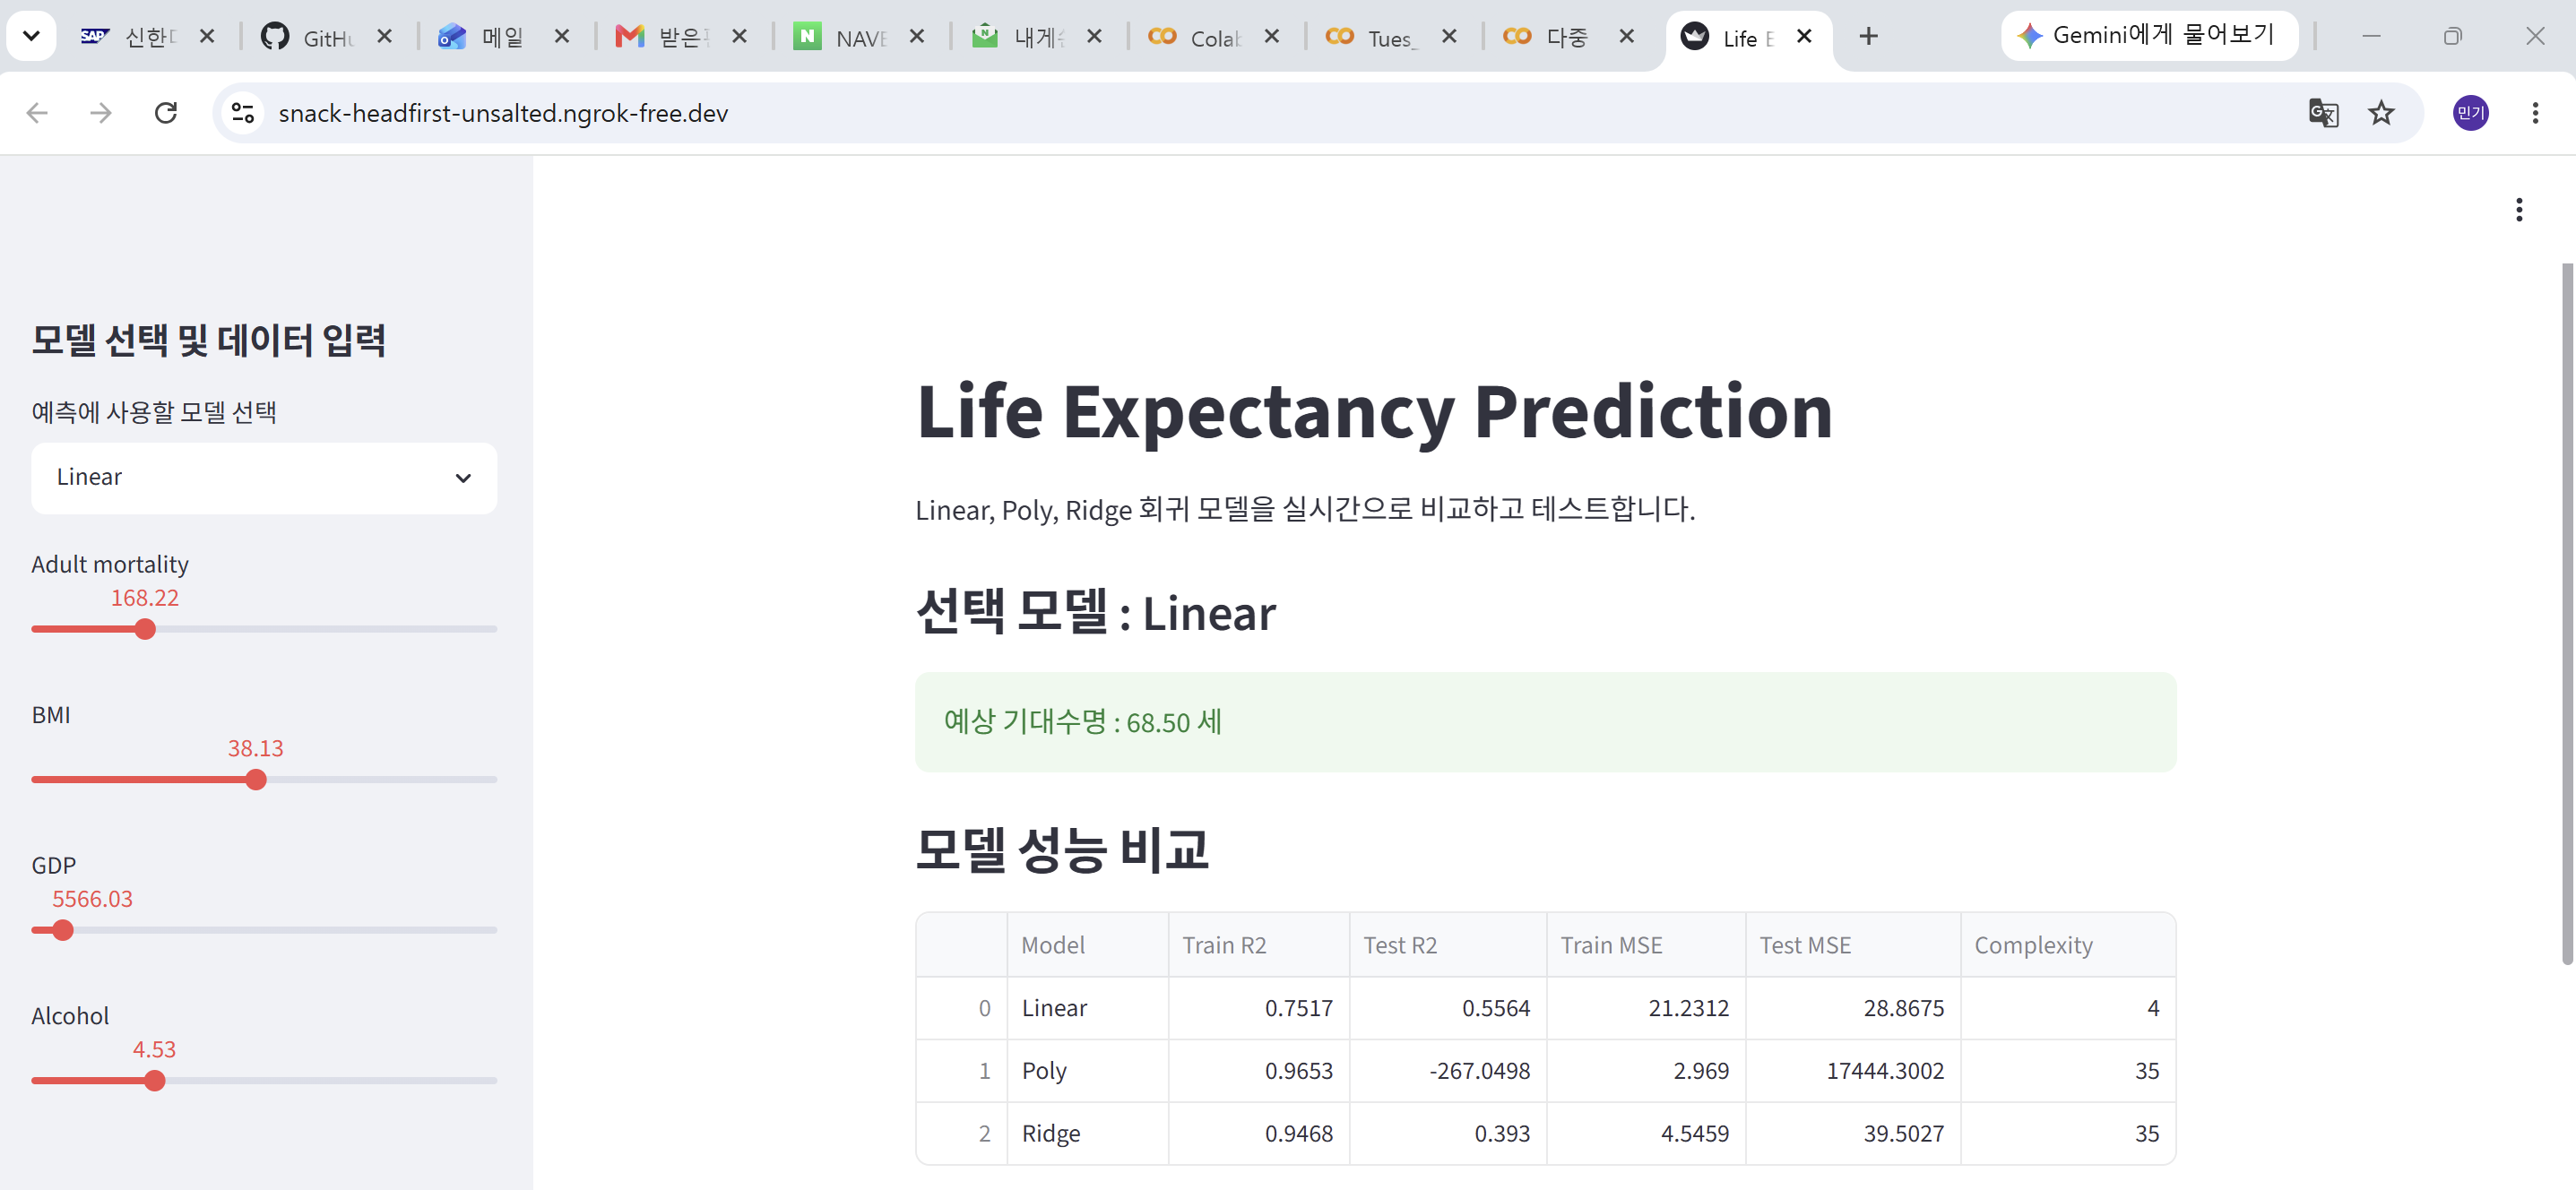

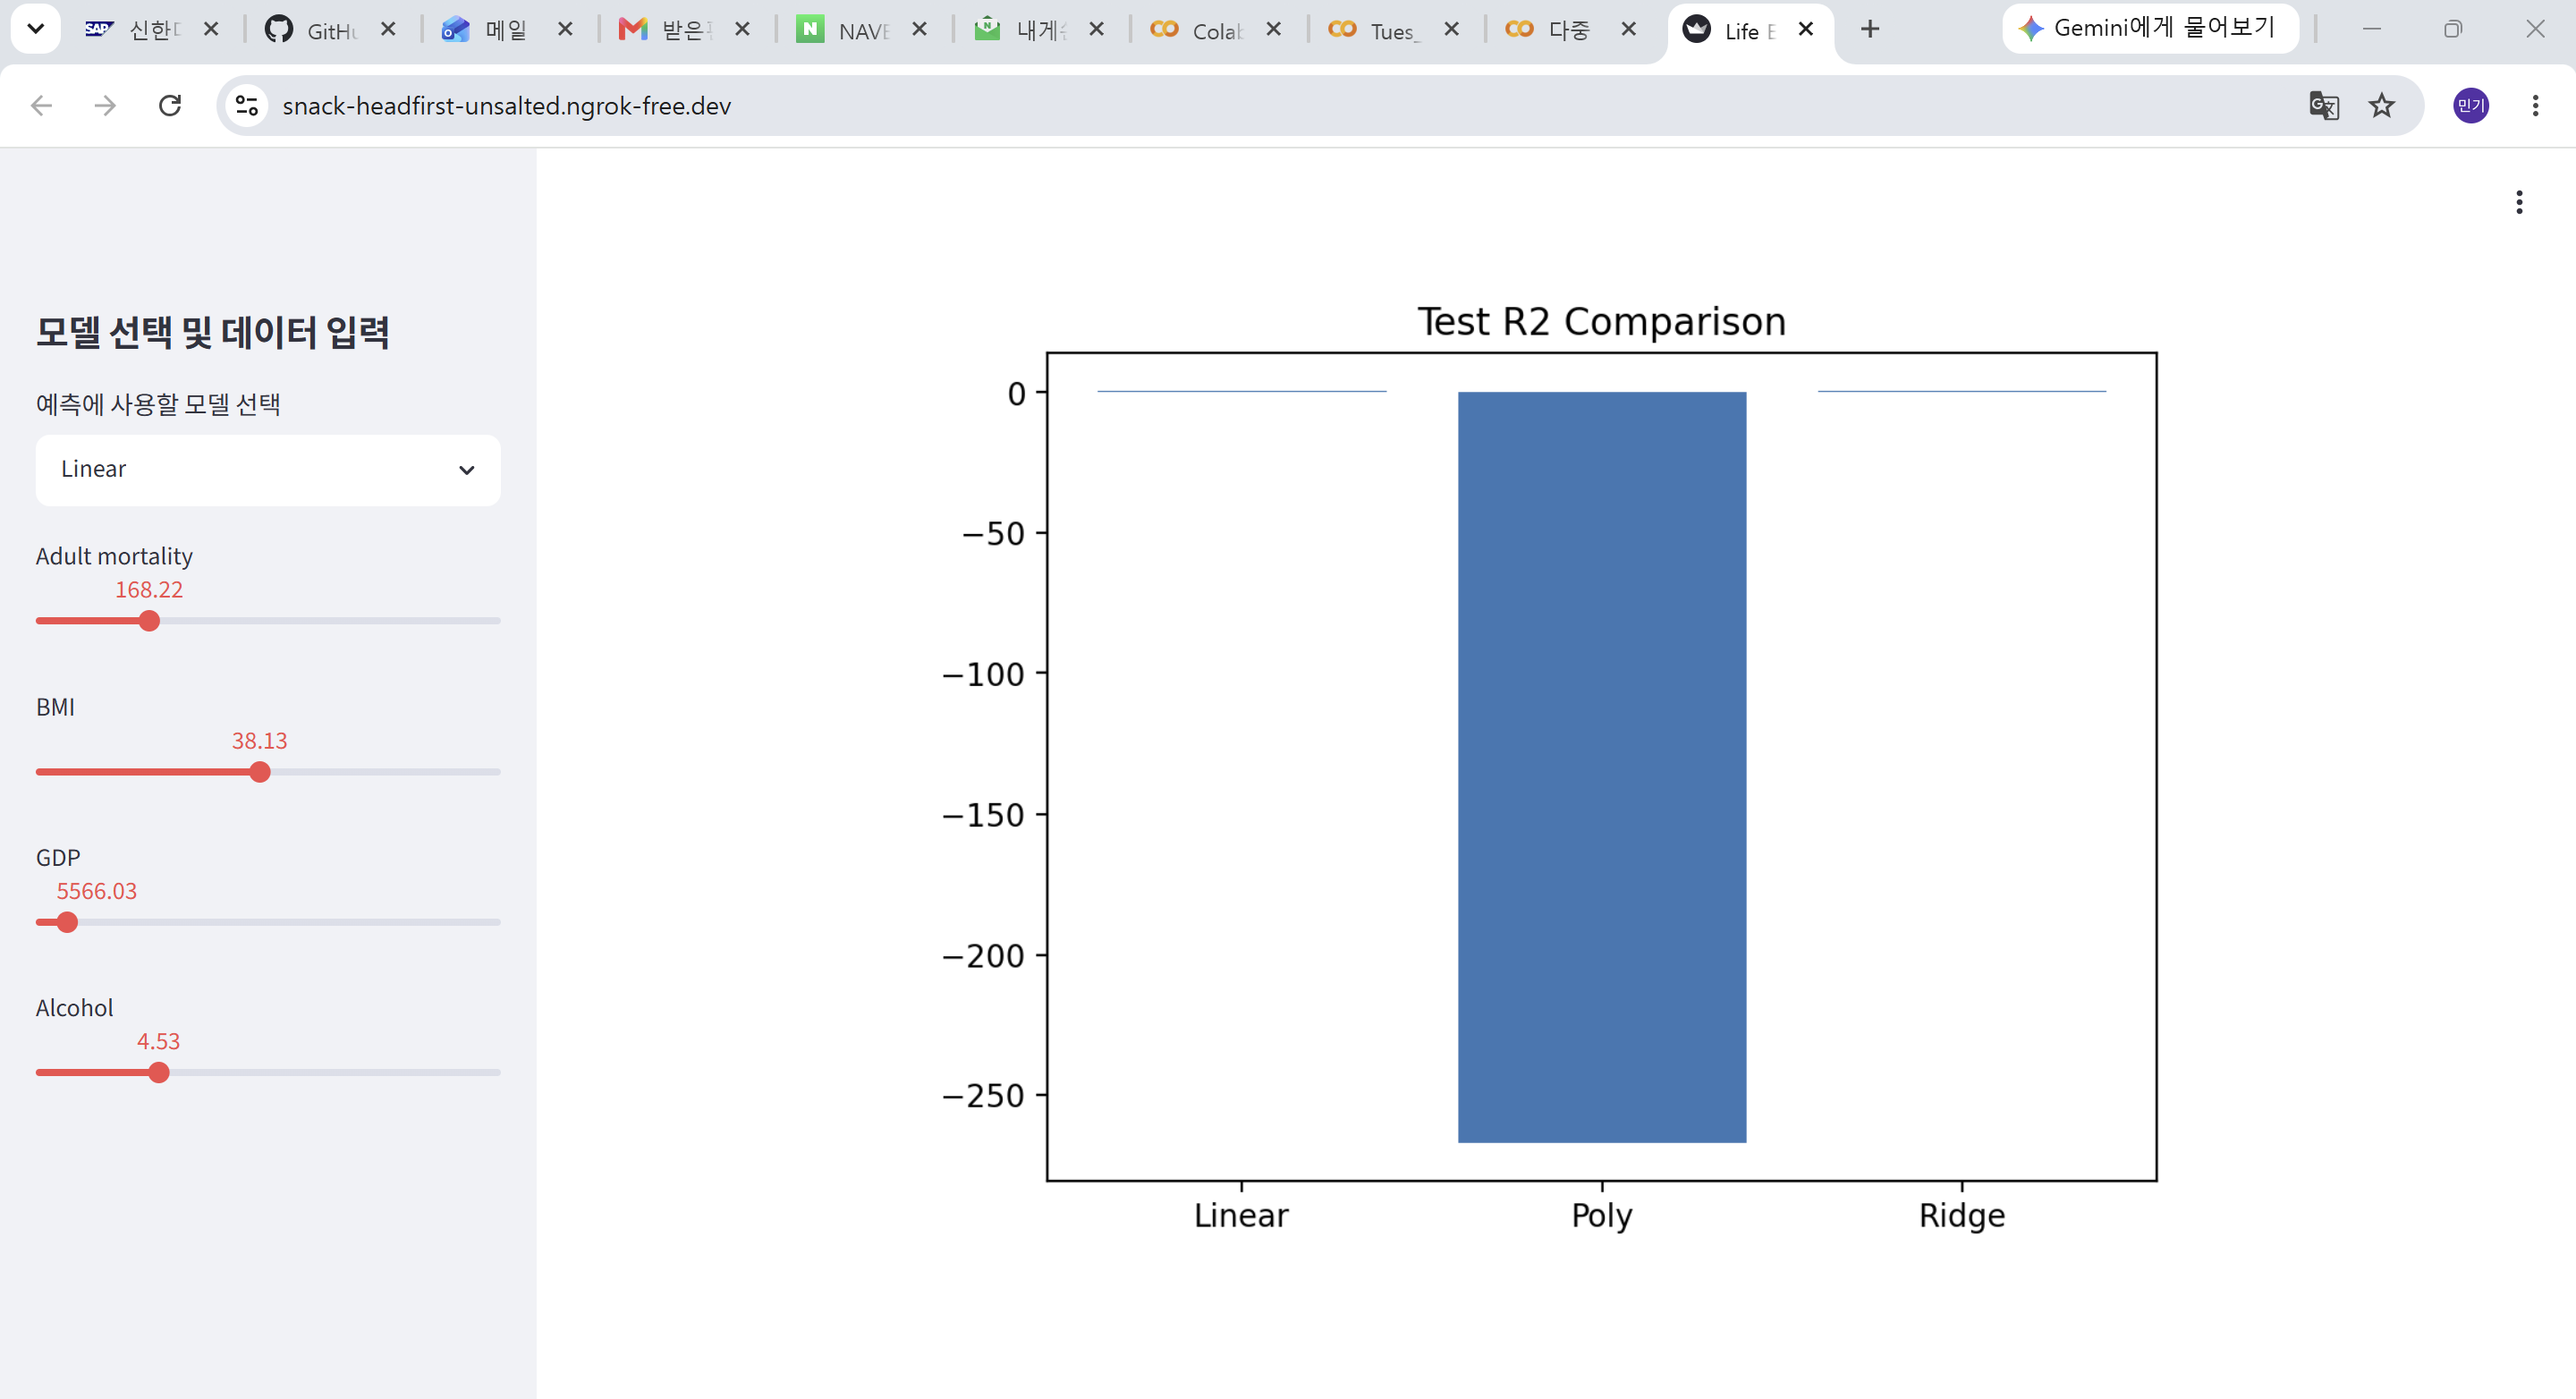